In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. TẢI DỮ LIỆU
file_path = "merged/data.csv"
df = pd.read_csv(file_path)
# Explore kiểu dữ liệu của tất cả các cột
try:
    
    print(" TỔNG QUAN DỮ LIỆU:")
    
    # Xem chi tiết 
    df.info()
    
    # In ra 5 dòng ngẫu nhiên để xem chuỗi "10%" hay "10" 
    print(df.sample(5))

except FileNotFoundError:
    print("Không tìm thấy file csv.")

 TỔNG QUAN DỮ LIỆU:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19817 entries, 0 to 19816
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_id                    19817 non-null  int64  
 1   product_name                  19817 non-null  object 
 2   product_url                   19817 non-null  object 
 3   category_id                   19817 non-null  int64  
 4   category_name                 19817 non-null  object 
 5   category_root_name            19817 non-null  object 
 6   price                         19811 non-null  float64
 7   original_price                19811 non-null  float64
 8   discount_rate                 19811 non-null  float64
 9   quantity_sold                 14172 non-null  float64
 10  rating_average                19811 non-null  float64
 11  review_count                  19811 non-null  float64
 12  is_return_policy              19811 non-

# Data cleaning

Ta thấy được `return_rate` và `cancel_by_seller_rate` chưa đúng với định dạng float của tỉ lệ. Có dòng dữ liệu đang chứa thêm kí tự "%" còn có dòng thì không.

In [2]:
# SỬA ĐỔI KIỂU DỮ LIỆU (DATA TYPE CONVERSION)

# Hàm xử lý các cột % (có ký tự %) thành số thực (float)
def clean_percentage(x):
    """Hàm làm sạch chuỗi phần trăm: '12%' -> 12.0, '<1%' -> 0.5"""
    if pd.isna(x): 
        return 0.0
    x = str(x).strip()
    
    # Xử lý trường hợp đặc biệt "<1%"
    if '<' in x:
        return 0.5 # Gán giá trị nhỏ tượng trưng
    
    # Loại bỏ ký tự % và chuyển sang float
    clean_val = x.replace('%', '').replace(' ', '')
    try:
        return float(clean_val)
    except:
        return 0.0

# Áp dụng cho 2 cột tỷ lệ
df['cancel_by_seller_rate'] = df['cancel_by_seller_rate'].apply(clean_percentage)
df['return_rate'] = df['return_rate'].apply(clean_percentage)

# Chuyển đổi các cột số khác để chắc chắn 
cols_to_numeric = ['price', 'original_price', 'quantity_sold', 'total_follower', 'review_count']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(df[['cancel_by_seller_rate', 'return_rate']].dtypes)

cancel_by_seller_rate    float64
return_rate              float64
dtype: object


In [3]:
# Xử lý data conflict ở discount_rate
df['discount_rate'] = abs(df['original_price']/df['price'] - 1)

# Data Reduction

- Phân loại cột theo dạng: Numeric, ID, Binary, Text


In [4]:
# Lựa chọn các cột numeric để drop các cột không cần thiết
num_cols = ['price', 'original_price', 'quantity_sold', 'total_follower', 
            'review_count', 'cancel_by_seller_rate', 'return_rate', 'discount_rate',
            'image_count', 'video_count', 'review_count', 'store_review_count']
# Tính toán count, mean, std, min, max cho các cột số, vẽ bảng thống kê bằng matplotlib
desc = df[num_cols].describe()
print("\nTHỐNG KÊ CÁC CỘT SỐ:")
print(desc)


THỐNG KÊ CÁC CỘT SỐ:
              price  original_price  quantity_sold  total_follower  \
count  1.981700e+04    1.981700e+04   19817.000000    19817.000000   
mean   2.140460e+06    2.285837e+06     535.181309    36269.361205   
std    1.795468e+07    1.810952e+07    7414.363610   128162.224157   
min    0.000000e+00    0.000000e+00       0.000000        0.000000   
25%    1.020000e+05    1.180000e+05       0.000000       36.000000   
50%    2.300000e+05    2.590000e+05       5.000000      290.000000   
75%    5.900000e+05    6.600000e+05      43.000000     1593.000000   
max    1.303175e+09    1.303175e+09  671583.000000   511829.000000   

       review_count  cancel_by_seller_rate  return_rate  discount_rate  \
count  19817.000000                19817.0      19817.0   19811.000000   
mean      29.819397                    0.0          0.0       0.139713   
std      212.640211                    0.0          0.0       0.268097   
min        0.000000                    0.0         

In [5]:
# Xử lý các cột text (text columns) xem cột nào chỉ có 1 giá trị duy nhất để drop
for col in df.select_dtypes(include=['object']).columns:
    unique_vals = df[col].nunique()
    if unique_vals == 1:
        print(f"Cột '{col}' có 1 giá trị duy nhất.")


Cột 'cancel_by_seller_rate_status' có 1 giá trị duy nhất.
Cột 'return_rate_status' có 1 giá trị duy nhất.


In [6]:
# Kiểm tra các cột binary có duy nhất 1 giá trị không
binary_cols = ['is_return_policy', 'is_freeship_xtra','is_authentic', 'is_brand', 'is_official']
for col in binary_cols:
    unique_vals = df[col].nunique()
    print(f"Cột '{col}' có {unique_vals} giá trị duy nhất.")
    if unique_vals == 1:
        print(f"Cột {col} có 1 giá trị duy nhất" )

Cột 'is_return_policy' có 2 giá trị duy nhất.
Cột 'is_freeship_xtra' có 2 giá trị duy nhất.
Cột 'is_authentic' có 2 giá trị duy nhất.
Cột 'is_brand' có 2 giá trị duy nhất.
Cột 'is_official' có 2 giá trị duy nhất.


- Các cột **numeric**: drop cột `return_rate` và `cancel_by_seller_rate` do không có giá trị dự đoán.
- Các cột **text**: 
    + Drop cột `cancel_by_seller_rate_status` và `return_rate_status` do chỉ có 1 giá trị dự đoán.
    + Drop cột `product_url` do chỉ mang tính chất phân biệt sản phẩm, không có giá trị dự đoán
    + Drop cột `store_name`,`brand_name` ,`category_name` và chỉ giữ lại `category_root_name` để tránh chi tiết hóa và tránh model học vẹt.
- Các cột **ID**:
    + Drop tất cả các cột bao gồm `product_id`, `category_id` và `store_id` do ID chỉ dùng để định danh.
- Các cột **binary**: giữ nguyên


In [7]:
drop_cols = ['cancel_by_seller_rate', 'return_rate',
             'cancel_by_seller_rate_status', 'return_rate_status', 'product_url',
             'category_name', 'store_name', 'brand_name',
             'product_id', 'store_id', 'category_id']
df.drop(columns=drop_cols, inplace=True)

# In ra 5 dòng ngẫu nhiên để xem data đã thay đổi 
print(df.sample(5))

                                            product_name   category_root_name  \
7180   Mật ong nguyên chất hoa cà phê loại 150g (lọ t...                 NGON   
7610                  Bánh Phô Mai Nướng Xém – Sầu Riêng                 NGON   
19194  Nước hoa Nữ Cao Cấp Atelier Versace Iris D'éli...   Làm Đẹp - Sức Khỏe   
5685             Giày Sandal Nữ BIGGBEN Da Bò Thật SDN19        Giày - Dép nữ   
2715   Tăng cân tăng cơ nạc Rule 1 Clean Gainer 9.8lb...  Thể Thao – Dã Ngoại   

           price  original_price  discount_rate  quantity_sold  \
7180     49000.0         49000.0       0.000000            0.0   
7610    160000.0        160000.0       0.000000            0.0   
19194  6900000.0       8745000.0       0.267391            0.0   
5685    339000.0        500000.0       0.474926           13.0   
2715   1900000.0       1900000.0       0.000000            1.0   

       rating_average  review_count  is_return_policy  is_freeship_xtra  \
7180              0.0           0.0      

# Feature engineering

- `reputation_score`: điểm uy tín thực sự giữa `rating_average` và `review_count` (Rating 5 sao mà chỉ có 1 review thì không bằng 4.5 sao mà có 1000 review.)
- `trust_level`: điểm tín nhiệm là tổng giữa các flag uy tín `is_official`, `is_authentic` và `is_brand`
- `review_to_sold_ratio`: tỉ lệ tương tác so với lượt mua (`review_count`/(`quantity_sold`+1))
- `shop_potential`: đo độ nổi tiếng của shop dựa trên tổng của `store_review_count` và `total_follower`

***Phục vụ cho câu hỏi 2***
- `total_visuals`: tổng số lượng video và hình ảnh
- `has_video`: flag kiểm tra sản phẩm có video không

***Phục vụ cho câu hỏi 3***
- `discount_amount`: số tiền giảm thực tế (hiệu của `original_price` và `price`)
- `price_vs_category`: giá tương đối của sản phẩm so với danh mục, so sánh giá sản phẩm so với giá trung bình của tất cả các sản phẩm cùng danh mục. <1: rẻ hơn trung bình; >1: mắc hơn trung bình.

***Phục vụ cho câu hỏi 5***
- `hot_keyword_count`: đếm số lần xuất hiện những từ khóa "giật tít" có trong tiêu đề.

***Phục vụ cho câu hỏi 7***
- `name_length`: độ dài của tiêu đề
- `name_word_count`: số chữ của tiêu đề

In [8]:
import re
print("TẠO CÁC FEATURE MỚI")

# Reputation Score 
# Công thức: Rating * log(Review + 1).
df['reputation_score'] = df['rating_average'] * np.log1p(df['review_count'])

# Trust Level (Điểm tín nhiệm)
df['trust_level'] = (df['is_official'] + df['is_authentic'] + 
                     df['is_brand'])

# Review to Sold Ratio (Tỷ lệ tương tác)
# Công thức: Review / (Sold + 1)
df['review_to_sold_ratio'] = df['review_count'] / (df['quantity_sold'].fillna(0) + 1)

# Shop Potential (Độ nổi tiếng của Shop)
# Công thức: Store Review + Total Follower
df['shop_potential'] = df['store_review_count'].fillna(0) + df['total_follower'].fillna(0)

# Total Visuals (Tổng tư liệu hình ảnh)
df['total_visuals'] = df['image_count'].fillna(0) + df['video_count'].fillna(0)

# Has Video (Có video không?)
df['has_video'] = df['video_count'].apply(lambda x: 1 if x > 0 else 0)

# Discount Amount (Số tiền giảm thực tế)
df['discount_amount'] = df['original_price'] - df['price']
# Xử lý số âm (nếu có lỗi dữ liệu)
df['discount_amount'] = df['discount_amount'].apply(lambda x: x if x > 0 else 0)

#Price vs Category (Giá tương đối)
# So sánh giá sp với giá trung bình của danh mục đó
if 'category_root_name' in df.columns:
    # Tính giá trung bình của từng danh mục
    df['category_avg_price'] = df.groupby('category_root_name')['price'].transform('mean')
    # Tính tỷ lệ: Giá SP / (Giá TB + 1)
    df['price_vs_category'] = df['price'] / (df['category_avg_price'] + 1)
else:
    df['price_vs_category'] = 1.0 # Mặc định nếu thiếu cột category

# Drop cột category_avg_price sau khi dùng xong
df.drop(columns='category_avg_price', inplace=True, errors='ignore')

# Hot Keyword Count (Đếm từ khóa "giật tít")
# Danh sách các từ khóa hấp dẫn
keywords = ['chính hãng', 'cao cấp', 'freeship', 'xịn', 'hot', 'giảm', 'sale', 'tặng', 'combo', 'bảo hành', 'nhập khẩu', 'siêu rẻ']
pattern = '|'.join(keywords)

# Đếm số lần xuất hiện (count)
df['hot_keyword_count'] = df['product_name'].astype(str).str.lower().str.count(pattern).fillna(0).astype(int)

# Name Length (Độ dài tiêu đề - Ký tự)
df['name_length'] = df['product_name'].astype(str).apply(len)

# Name Word Count (Độ dài tiêu đề - Số từ)
df['name_word_count'] = df['product_name'].astype(str).apply(lambda x: len(x.split()))

# Drop cột product_name sau khi dùng xong
df.drop(columns='product_name', inplace=True, errors='ignore')

print("Đã tạo xong 11 feature mới theo yêu cầu.")

# Hiển thị 5 dòng đầu của các cột mới để kiểm tra
new_cols = ['reputation_score', 'trust_level', 'shop_potential', 
            'has_video', 'discount_amount', 'price_vs_category',
            'hot_keyword_count', 'name_word_count']
            
print(df[new_cols].head())



TẠO CÁC FEATURE MỚI
Đã tạo xong 11 feature mới theo yêu cầu.
   reputation_score  trust_level  shop_potential  has_video  discount_amount  \
0          4.943755          2.0         10284.0          0         100000.0   
1         13.862944          2.0          3184.0          1         100000.0   
2         11.512925          2.0          3184.0          1         100000.0   
3          6.931472          2.0         10284.0          0         100000.0   
4          9.729551          2.0          3184.0          1         100000.0   

   price_vs_category  hot_keyword_count  name_word_count  
0           1.219578                  1                7  
1           1.366599                  0               10  
2           1.294096                  0               10  
3           1.305126                  0                7  
4           1.228840                  0               10  
Đã tạo xong 11 feature mới theo yêu cầu.
   reputation_score  trust_level  shop_potential  has_video  di

In [9]:
# One-hot encoding cho category_root_name
from sklearn.model_selection import train_test_split
if 'category_root_name' in df.columns:
    df = pd.get_dummies(df, columns=['category_root_name'], drop_first=True, dtype=int)
    print("One-hot encoding cho category_root_name hoàn tất")

# Drop cột category_avg_price sau khi dùng xong
df.drop(columns='category_avg_price', inplace=True, errors='ignore')

# Ở dưới đây có thể là One-hot encoding của origin từ Mỹ Hạ

One-hot encoding cho category_root_name hoàn tất


# Standardization and Scaling

- Giữ nguyên các cột đang ở dạng binary
- Log Transform những feature bị lệch
- Sử dụng Min-Max Scaling cho tất cả các cột dạng numeric


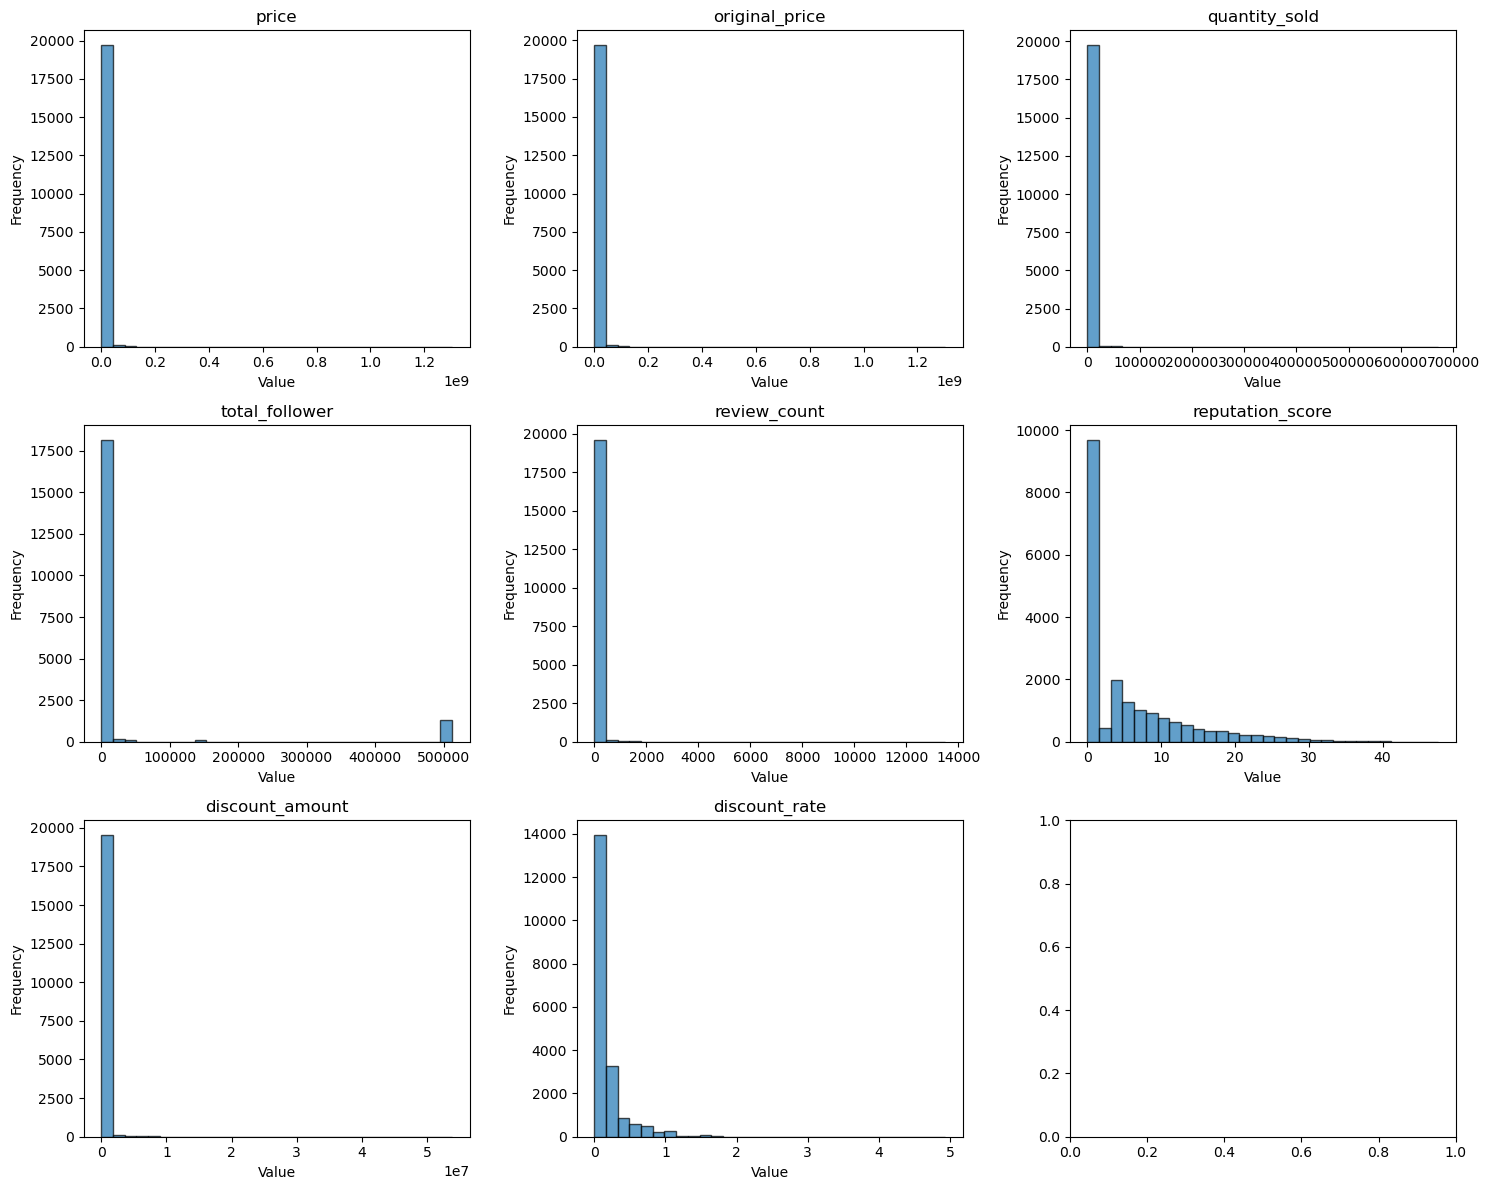

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Trực quan phân phối các cột numeric không dự đoán được min max - chỉ vẽ 1 lần để quyết định log transform
num_cols = ['price', 'original_price', 'quantity_sold', 'total_follower', 
            'review_count', 'reputation_score', 'discount_amount', 'discount_rate']

# Vẽ tất cả trong 1 hình (9 subplots)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Hầu như những cột nghi ngờ bị lệch đều lệch thật nên giải pháp chỉ áp dụng Min-Max Scaling là chưa đủ. Cần sử dụng Log Transformation cho các cột trên trước, sau đó dùng Min-Max Scaling cho tất cả các cột numeric.

In [11]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- CÁC CỘT CẦN ÁP DỤNG LOG TRANSFORMATION ---
# Các cột số lượng và giá trị lớn thường bị lệch phải
LOG_COLS = ['price', 'original_price', 'quantity_sold', 'review_count', 'total_follower',
            'reputation_score', 'discount_amount','discount_rate']

# 1. Áp dụng Log Transformation cho các cột bị lệch
for col in LOG_COLS:
    # Tạo cột mới với hậu tố '_log'
    # np.log1p(x) = log(1+x), an toàn khi x=0
    df[col] = np.log1p(df[col])
    
# 2. Định nghĩa lại các cột cần Scale (Bao gồm các cột đã Log)
# Loại bỏ các cột Binary (is_official, is_authentic, has_video, v.v.)
cols_to_scale = [col for col in df.columns 
                 if df[col].dtype in ['float64', 'int64'] 
                 and col not in ['is_official', 'is_authentic', 'is_brand', 
                                 'is_freeship_xtra', 'is_return_policy', 'has_video']]

# 3. Xử lý NaN và inf (Đã được thực hiện tốt trong code cũ)
df[cols_to_scale] = df[cols_to_scale].replace([np.inf, -np.inf], 0).fillna(0)

# 4. Áp dụng MinMaxScaler (0-1) cho tất cả các cột liên tục (đã log hoặc chưa)
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Đã Log-transform {len(LOG_COLS)} cột và Scale xong {len(cols_to_scale)} cột.")

Đã Log-transform 8 cột và Scale xong 19 cột.


In [13]:
# Ghi lại vào csv
# df.to_csv("tiki_data_preprocessed.csv", index=False, encoding='utf-8-sig')